# ADC Toxicity Classifier
Full pipeline: data loading, LOAOCV evaluation, final model training, SHAP analysis.

In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score, f1_score
from src.data_loader import load_data
from src.preprocessor import build_preprocessor, FEATURE_COLS, TARGET_REG, TARGET_CLF
from src.train import run_loaocv, RF_REG_PARAMS, RF_CLF_PARAMS, XGB_REG_PARAMS, XGB_CLF_PARAMS

df = load_data('data/TADC_Complete_v3_avec_S.xlsx')
print(df.shape)
df[['P','D','H','B','L','E','V','S(payload,organe)','%G\u22653 observ\u00e9','Y binaire (G\u22653 >10%)']].describe()

(106, 26)


,P,D,H,B,L,E,V,"S(payload,organe)",%G≥3 observé,Y binaire (G≥3 >10%)
count,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000
mean,1.811321,1.759434,1.254717,1.334906,1.566038,1.334906,1.392453,1.000094,9.027358,0.207547
std,0.684707,0.633325,0.651903,0.619991,0.759309,0.646314,0.369478,0.562016,14.727199,0.407477
min,1.000000,0.500000,0.500000,0.500000,0.500000,0.500000,1.000000,0.200000,0.000000,0.000000
25%,1.500000,1.500000,0.500000,0.500000,1.000000,1.000000,1.000000,0.627500,2.000000,0.000000
50%,1.500000,1.500000,1.500000,1.500000,1.500000,1.250000,1.300000,0.940000,3.250000,0.000000
75%,2.500000,2.000000,2.000000,2.000000,1.500000,1.500000,1.800000,1.200000,8.000000,0.000000
max,3.000000,3.000000,2.000000,2.000000,3.000000,2.500000,2.000000,2.810000,82.000000,1.000000


In [2]:
print('Class distribution (Y binaire):')
print(df['Y binaire (G\u22653 >10%)'].value_counts())
print('\nADC row counts:')
print(df['ADC'].value_counts())

Class distribution (Y binaire):
Y binaire (G≥3 >10%)
0.0    84
1.0    22
Name: count, dtype: int64

ADC row counts:
ADC
Enhertu     10
Mylotarg     8
Kadcyla      8
Padcev       8
Trodelvy     8
Zynlonta     8
Tivdak       8
Adcetris     7
Besponsa     7
Blenrep      7
Elahere      7
Datroway     7
Teliso-V     7
Polivy       6
Name: count, dtype: int64


In [3]:
reg_results = run_loaocv(df, task='regression')
print(f"Regression LOAOCV \u2014 MAE: {reg_results['mae']:.2f}  RMSE: {reg_results['rmse']:.2f}  R\u00b2: {reg_results['r2']:.3f}")

Regression LOAOCV — MAE: 5.71  RMSE: 10.57  R²: 0.480


In [4]:
clf_results = run_loaocv(df, task='classification')
print(f"Classification LOAOCV \u2014 AUC: {clf_results['auc']:.3f}  F1: {clf_results['f1']:.3f}  Acc: {clf_results['accuracy']:.3f}")

Classification LOAOCV — AUC: 0.823  F1: 0.500  Acc: 0.792


In [5]:
baseline_pred_reg = df['T-ADC v3 = \u03a3\u00d7V\u00d7S'].values
baseline_true_reg = df[TARGET_REG].values
baseline_mae = mean_absolute_error(baseline_true_reg, baseline_pred_reg)
print(f'Baseline (T-ADC v3) MAE: {baseline_mae:.2f}')
print(f'ML LOAOCV MAE:          {reg_results["mae"]:.2f}')

Baseline (T-ADC v3) MAE: 15.31
ML LOAOCV MAE:          5.71


In [6]:
preprocessor = build_preprocessor()
X_all = preprocessor.fit_transform(df[FEATURE_COLS])
y_reg_all = df[TARGET_REG].values.astype(float)
y_clf_all = df[TARGET_CLF].values.astype(int)

# Regression
gs_reg = GridSearchCV(
    RandomForestRegressor(random_state=42),
    RF_REG_PARAMS, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1
)
gs_reg.fit(X_all, y_reg_all)
best_reg = gs_reg.best_estimator_

# Classification
gs_clf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    RF_CLF_PARAMS, cv=5, scoring='roc_auc', n_jobs=-1
)
gs_clf.fit(X_all, y_clf_all)
best_clf = gs_clf.best_estimator_

joblib.dump(best_reg, 'models/model_regression.pkl')
joblib.dump(best_clf, 'models/model_classification.pkl')
joblib.dump(preprocessor, 'models/preprocessor.pkl')
print('Models saved.')

Models saved.


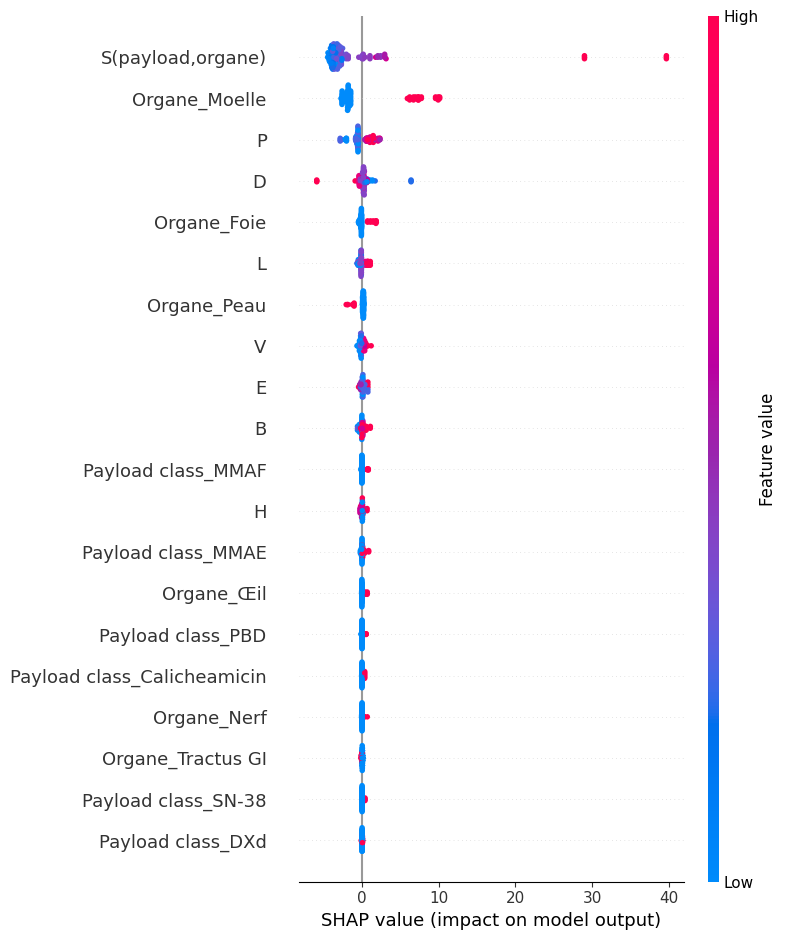

In [7]:
explainer_reg = shap.TreeExplainer(best_reg)
shap_values_reg = explainer_reg.shap_values(X_all)

feature_names = (
    list(preprocessor.named_transformers_['num'].get_feature_names_out())
    + list(preprocessor.named_transformers_['cat'].get_feature_names_out())
)

shap.summary_plot(shap_values_reg, X_all, feature_names=feature_names, show=True)

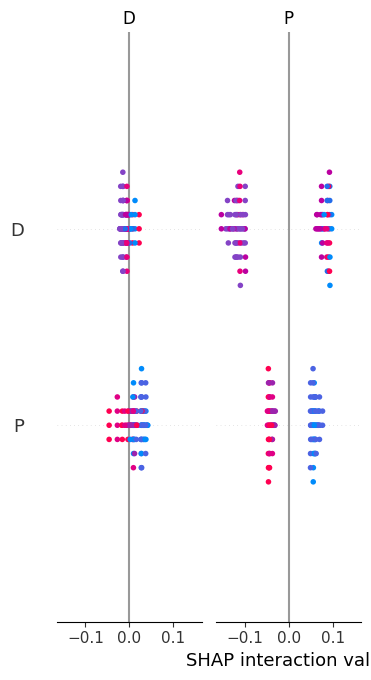

In [8]:
explainer_clf = shap.TreeExplainer(best_clf)
shap_values_clf = explainer_clf.shap_values(X_all)
if isinstance(shap_values_clf, list):
    shap_values_clf = shap_values_clf[1]  # positive class

shap.summary_plot(shap_values_clf, X_all, feature_names=feature_names, show=True)